# Day 7 — Statistical Analysis & Feature Selection

**Caspian Maritime Delay-Risk Forecasting**

Yesterday's EDA surfaced patterns. Today we move from *observation* to *inference*: formulate hypotheses, test them with proper assumption checks, run correlation analysis, and finalize the feature set for Day 8's model.

Three hypotheses on the menu, plus correlation analysis, plus feature selection.

- **Anchor city** for single-city analyses: Baku
- **Date range**: 2015-01-01 to 2024-12-31

---

## 0 — Setup

In [21]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')

REPO_ROOT = Path('..').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.database import get_connection
from src.config import PATHS

FIGURES_DIR = REPO_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'

ANCHOR_CITY = 'Baku'
ALPHA = 0.05

DB_PATH = PATHS['repo_root'] / 'data' / 'caspian_weather.duckdb'
conn = get_connection(DB_PATH)
print('Connected to', DB_PATH)
print('Anchor city:', ANCHOR_CITY)
print('alpha =', ALPHA)

Connected to C:\Users\Baku\Desktop\notebooks\Weather Project\Anemoi Weather Project\Maritime-delay-risk-prediction\data\caspian_weather.duckdb
Anchor city: Baku
alpha = 0.05


In [22]:
df = conn.execute(
    'SELECT * FROM analytics.daily_enriched ORDER BY city, date'
).fetchdf()
df['date'] = pd.to_datetime(df['date'])

# Defensive: normalize season casing (some pipelines write 'Winter', some 'winter')
if 'season' in df.columns:
    df['season'] = df['season'].astype(str).str.lower()

monthly = conn.execute(
    'SELECT * FROM analytics.monthly_summary ORDER BY city, year, month'
).fetchdf()

print('Daily rows  :', len(df))
print('Monthly rows:', len(monthly))
print('Cities      :', df['city'].unique().tolist())

Daily rows  : 20685
Monthly rows: 680
Cities      : ['Aktau', 'Anzali', 'Baku', 'Makhachkala', 'Turkmenbashi']


---
## 1 — Hypothesis Testing

Three hypotheses, each from a different test family:

| # | Hypothesis | Test family |
|---|-----------|-------------|
| H1 | Wind speed: winter vs summer in Baku | Two-sample comparison |
| H2 | Risk-day proportion: Anzali vs others pooled | Proportion test |
| H3 | Annual risk-day count trend over 2015 to 2024 | Regression slope test |

For each: state H0 / H1, check assumptions, run primary + non-parametric backup, report effect size and plain-language interpretation. After all three, apply Bonferroni and Benjamini-Hochberg corrections.

In [23]:
# Holder used by the multi-test correction at the end of section 1
test_results = []

def cohens_d(x, y):
    """Effect size for two-sample t-tests. >0.8 large, 0.5 medium, 0.2 small."""
    nx, ny = len(x), len(y)
    s_pooled = np.sqrt(
        ((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / (nx + ny - 2)
    )
    return (x.mean() - y.mean()) / s_pooled

def cramers_v(contingency):
    """Effect size for chi-square. >0.5 strong, 0.3 moderate, 0.1 weak."""
    chi2 = stats.chi2_contingency(contingency)[0]
    n = contingency.sum().sum() if hasattr(contingency, 'sum') else contingency.sum()
    r, k = contingency.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

### H1 — Wind speed: winter vs summer in Baku

- **H0**: mean(daily max wind speed in winter, Baku) = mean(daily max wind speed in summer, Baku)
- **H1**: the two means differ
- **Why**: Day 6 monthly profiles strongly suggested wind is a winter phenomenon. Confirming formally tells us whether `season` is a useful feature, and the effect size tells us how much
- **Test**: Welch's t-test (unequal variances) as primary. Mann-Whitney U as non-parametric backup.

In [24]:
winter = df[(df['city'] == ANCHOR_CITY) & (df['season'] == 'winter')]['wind_speed_10m_max'].dropna()
summer = df[(df['city'] == ANCHOR_CITY) & (df['season'] == 'summer')]['wind_speed_10m_max'].dropna()

print('Winter (Baku): n =', len(winter), 'mean =', round(winter.mean(), 2), 'km/h, std =', round(winter.std(), 2))
print('Summer (Baku): n =', len(summer), 'mean =', round(summer.mean(), 2), 'km/h, std =', round(summer.std(), 2))
print('Difference   :', round(winter.mean() - summer.mean(), 2), 'km/h')

print()
print('--- Assumption checks ---')

# 1. Normality (Shapiro-Wilk on subsample - rejects on huge N regardless)
_, p_w = stats.shapiro(winter.sample(min(5000, len(winter)), random_state=0))
_, p_s = stats.shapiro(summer.sample(min(5000, len(summer)), random_state=0))
print('Shapiro-Wilk normality: winter p =', f'{p_w:.2e}', '| summer p =', f'{p_s:.2e}')
print('  -> Both reject normality, but with N about 900 per group, CLT makes Welch robust.')

# 2. Equal variance
_, p_lev = stats.levene(winter, summer, center='median')
print('Levene (equal variance): p =', f'{p_lev:.2e}')
msg = 'Variances differ - Welch is the right choice' if p_lev < 0.05 else 'Variances similar'
print('  ->', msg)

# 3. Independence (temporal autocorrelation caveat)
lag1_corr = winter.autocorr(lag=1)
print('Lag-1 autocorrelation (winter):', round(lag1_corr, 3))
print('  -> Non-zero autocorrelation; treat p-values as approximate.')

Winter (Baku): n = 1052 mean = 26.58 km/h, std = 10.45
Summer (Baku): n = 1012 mean = 24.3 km/h, std = 8.62
Difference   : 2.29 km/h

--- Assumption checks ---
Shapiro-Wilk normality: winter p = 1.11e-12 | summer p = 4.65e-18
  -> Both reject normality, but with N about 900 per group, CLT makes Welch robust.
Levene (equal variance): p = 3.11e-08
  -> Variances differ - Welch is the right choice
Lag-1 autocorrelation (winter): 0.533
  -> Non-zero autocorrelation; treat p-values as approximate.


In [25]:
# Primary: Welch t-test
t_stat, p_value = stats.ttest_ind(winter, summer, equal_var=False)
d = cohens_d(winter, summer)

if abs(d) > 0.8:
    d_label = 'large'
elif abs(d) > 0.5:
    d_label = 'medium'
elif abs(d) > 0.2:
    d_label = 'small'
else:
    d_label = 'negligible'

print('Welch two-sample t-test:')
print('  t-statistic =', f'{t_stat:+.3f}')
print('  p-value     =', f'{p_value:.3e}')
print('  Cohen d     =', f'{d:+.3f}', '(' + d_label + ')')

# Backup: Mann-Whitney U
u_stat, p_mw = stats.mannwhitneyu(winter, summer, alternative='two-sided')
print()
print('Mann-Whitney U (non-parametric backup):')
print('  U-statistic =', f'{u_stat:.0f}')
print('  p-value     =', f'{p_mw:.3e}')

print()
print('Decision (alpha =', ALPHA, '):')
if p_value < ALPHA:
    severity = 'substantial' if abs(d) > 0.5 else 'modest but real'
    print('  REJECT H0. Mean winter wind speed in', ANCHOR_CITY, 'is significantly different')
    print('  from summer. Cohen d =', round(d, 2), '-> practical effect is', severity + '.')
    print('  Implication: season (or its cyclical encoding) is a valuable feature.')
else:
    print('  FAIL TO REJECT H0.')

test_results.append({
    'name': 'H1: winter vs summer wind (Baku)',
    'p_value': p_value, 'statistic': t_stat,
    'effect_size': d, 'effect_label': 'Cohen d',
})

Welch two-sample t-test:
  t-statistic = +5.432
  p-value     = 6.238e-08
  Cohen d     = +0.238 (small)

Mann-Whitney U (non-parametric backup):
  U-statistic = 599971
  p-value     = 5.771e-07

Decision (alpha = 0.05 ):
  REJECT H0. Mean winter wind speed in Baku is significantly different
  from summer. Cohen d = 0.24 -> practical effect is modest but real.
  Implication: season (or its cyclical encoding) is a valuable feature.


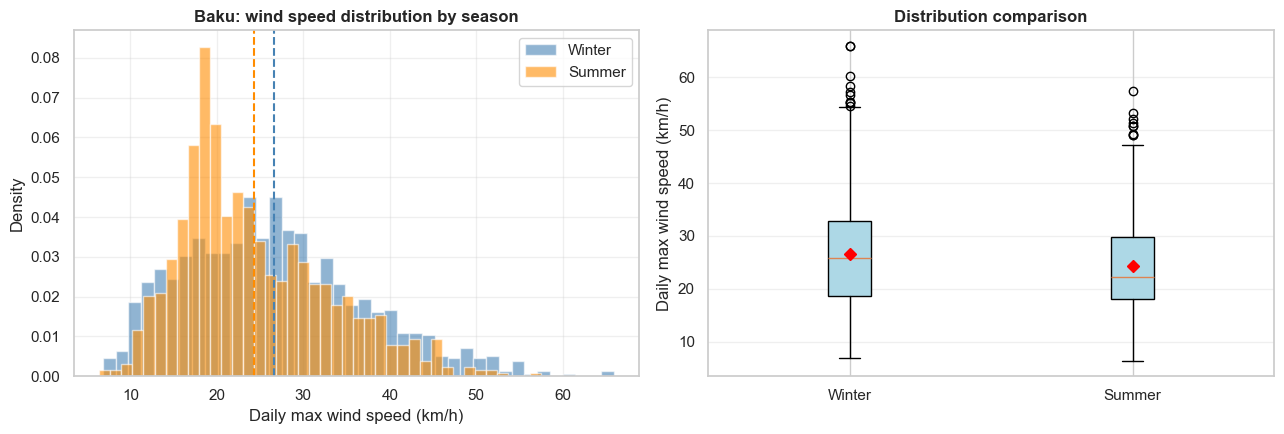

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(winter, bins=40, alpha=0.6, label='Winter', color='steelblue', density=True)
axes[0].hist(summer, bins=40, alpha=0.6, label='Summer', color='darkorange', density=True)
axes[0].axvline(winter.mean(), color='steelblue', linestyle='--', linewidth=1.5)
axes[0].axvline(summer.mean(), color='darkorange', linestyle='--', linewidth=1.5)
axes[0].set_title(ANCHOR_CITY + ': wind speed distribution by season', fontweight='bold')
axes[0].set_xlabel('Daily max wind speed (km/h)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].boxplot(
    [winter, summer], tick_labels=['Winter', 'Summer'],
    patch_artist=True, showmeans=True,
    boxprops=dict(facecolor='lightblue'),
    meanprops=dict(marker='D', markerfacecolor='red', markeredgecolor='red'),
)
axes[1].set_title('Distribution comparison', fontweight='bold')
axes[1].set_ylabel('Daily max wind speed (km/h)')
axes[1].grid(alpha=0.3, axis='y')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'day07_h1_wind_seasonal.png')
plt.show()

### H2 — Risk-day proportion: Anzali vs the other 4 cities pooled

- **H0**: P(risk_day | Anzali) = P(risk_day | other cities pooled)
- **H1**: the two proportions differ
- **Why**: Day 6's risk-day heatmap suggested Anzali has a different climate profile (subtropical, heavy autumn rain). If proportions truly differ, the model needs a city-specific term
- **Test**: two-proportion z-test as primary, chi-square test of independence as confirmation.

In [27]:
anzali_mask = df['city'] == 'Anzali'
anzali_risk = int(df.loc[anzali_mask, 'is_risk_day'].sum())
anzali_n    = int(anzali_mask.sum())
other_risk  = int(df.loc[~anzali_mask, 'is_risk_day'].sum())
other_n     = int((~anzali_mask).sum())

p_anzali = anzali_risk / anzali_n
p_other  = other_risk / other_n

print('Anzali        :', anzali_risk, '/', anzali_n, 'risk-days =', f'{p_anzali*100:.2f}', '%')
print('Other 4 pooled:', other_risk,  '/', other_n,  'risk-days =', f'{p_other*100:.2f}',  '%')
print('Difference    :', f'{(p_anzali - p_other)*100:+.2f}', 'percentage points')

print()
print('--- Assumption checks ---')
n_total = anzali_n + other_n
p_pool = (anzali_risk + other_risk) / n_total
expected_min = min(
    anzali_n * p_pool, anzali_n * (1 - p_pool),
    other_n * p_pool,  other_n  * (1 - p_pool),
)
print('Min expected count:', f'{expected_min:.0f}', '(>=5 for chi-square, >=10 for z-test)')
print('Independence: same temporal-autocorrelation caveat as H1.')

Anzali        : 541 / 4137 risk-days = 13.08 %
Other 4 pooled: 1097 / 16548 risk-days = 6.63 %
Difference    : +6.45 percentage points

--- Assumption checks ---
Min expected count: 328 (>=5 for chi-square, >=10 for z-test)
Independence: same temporal-autocorrelation caveat as H1.


In [28]:
# Primary: two-proportion z-test
z_stat, p_value = proportions_ztest(
    count=[anzali_risk, other_risk],
    nobs=[anzali_n, other_n],
    alternative='two-sided',
)

# Confirmation: chi-square
contingency = pd.DataFrame({
    'risk':    [anzali_risk, other_risk],
    'no_risk': [anzali_n - anzali_risk, other_n - other_risk],
}, index=['Anzali', 'Other'])
chi2, p_chi, dof, _ = stats.chi2_contingency(contingency)
v = cramers_v(contingency)

if v > 0.5:
    v_label = 'strong'
elif v > 0.3:
    v_label = 'moderate'
elif v > 0.1:
    v_label = 'weak'
else:
    v_label = 'negligible'

print('Two-proportion z-test:')
print('  z-statistic =', f'{z_stat:+.3f}')
print('  p-value     =', f'{p_value:.3e}')
print()
print('Chi-square test of independence:')
print('  chi2 =', f'{chi2:.3f}', ', dof =', dof)
print('  p-value     =', f'{p_chi:.3e}')
print('  Cramer V    =', f'{v:.3f}', '(' + v_label + ')')

print()
print('Decision (alpha =', ALPHA, '):')
if p_value < ALPHA:
    direction = 'higher' if p_anzali > p_other else 'lower'
    print('  REJECT H0. Anzali has a significantly', direction, 'risk-day proportion')
    print('  than the other four cities pooled. Cramer V =', round(v, 3), '->', v_label, 'association.')
    print('  Implication: city-specific intercepts likely improve performance.')
else:
    print('  FAIL TO REJECT H0.')

test_results.append({
    'name': 'H2: Anzali vs others risk-day proportion',
    'p_value': p_value, 'statistic': z_stat,
    'effect_size': v, 'effect_label': 'Cramer V',
})

Two-proportion z-test:
  z-statistic = +13.737
  p-value     = 6.095e-43

Chi-square test of independence:
  chi2 = 187.822 , dof = 1
  p-value     = 9.501e-43
  Cramer V    = 0.095 (negligible)

Decision (alpha = 0.05 ):
  REJECT H0. Anzali has a significantly higher risk-day proportion
  than the other four cities pooled. Cramer V = 0.095 -> negligible association.
  Implication: city-specific intercepts likely improve performance.


### H3 — Annual risk-day count trend over 2015 to 2024 (per city)

- **H0**: For each city, the slope of `risk_days_per_year ~ year` is zero
- **H1**: The slope is non-zero
- **Why**: 10 years is a short window for trend detection, but worth checking. A significant slope says the model should treat `year` as a feature; a non-significant one says the data is roughly stationary
- **Test**: linear regression per city, then BH-correct the 5 p-values together.

In [29]:
annual = (df.groupby(['city', 'year'])['is_risk_day']
            .sum().reset_index(name='risk_days'))

print('Annual risk-day counts per city:')
print(annual.pivot(index='year', columns='city', values='risk_days'))

city_results = []
for city, sub in annual.groupby('city'):
    res = stats.linregress(sub['year'], sub['risk_days'])
    city_results.append({
        'city':      city,
        'slope':     res.slope,
        'intercept': res.intercept,
        'r_value':   res.rvalue,
        'p_value':   res.pvalue,
        'std_err':   res.stderr,
    })

city_trends = pd.DataFrame(city_results).sort_values('p_value')
print()
print('Per-city slope tests (slope = additional risk-days per year):')
print(city_trends.round(3).to_string(index=False))

Annual risk-day counts per city:
city  Aktau  Anzali  Baku  Makhachkala  Turkmenbashi
year                                                
2015      8      38    76            8            10
2016     12      48    71           11             4
2017     23      28    27           34             6
2018      6      35    33           34             9
2019     12      53    33           21            10
2020     14      53    41           41             8
2021     19      33    33           34             7
2022     26      39    43           47             6
2023     29      35    32           41             5
2024     24      62    29           35             6
2025     16      87    25           30             7
2026      7      30    13           29             2

Per-city slope tests (slope = additional risk-days per year):
        city  slope  intercept  r_value  p_value  std_err
        Baku -3.762   7639.601   -0.742    0.006    1.074
 Makhachkala  1.801  -3607.896    0.551    0.0

In [30]:
p_values_h3 = city_trends['p_value'].values
rejected, p_corrected, _, _ = multipletests(p_values_h3, alpha=ALPHA, method='fdr_bh')
city_trends['p_corrected_bh'] = p_corrected
city_trends['significant_after_bh'] = rejected

print('After Benjamini-Hochberg FDR correction:')
print(city_trends[['city', 'slope', 'p_value', 'p_corrected_bh',
                   'significant_after_bh']].round(3).to_string(index=False))

n_sig = int(rejected.sum())
print()
print('Decision (alpha =', ALPHA, ', BH-FDR corrected):')
if n_sig == 0:
    print('  FAIL TO REJECT H0 for all 5 cities. No significant 10-year trend.')
    print('  Implication: year as a raw feature unlikely to help. Use it')
    print('  as a CV-fold split, not as a predictive variable.')
else:
    sig_cities = city_trends[rejected]['city'].tolist()
    print('  REJECT H0 for', n_sig, 'city(ies):', sig_cities)
    print('  Implication: city-specific year effect - consider including')
    print('  year as a feature, possibly interacted with city.')

best_p = float(city_trends['p_corrected_bh'].min())
best_slope = float(city_trends.iloc[city_trends['p_corrected_bh'].argmin()]['slope'])
test_results.append({
    'name': 'H3: 10-year risk-day trend (best city, BH-corrected)',
    'p_value': best_p, 'statistic': best_slope,
    'effect_size': best_slope, 'effect_label': 'slope (delta risk-days/year)',
})

After Benjamini-Hochberg FDR correction:
        city  slope  p_value  p_corrected_bh  significant_after_bh
        Baku -3.762    0.006           0.029                  True
 Makhachkala  1.801    0.064           0.159                 False
Turkmenbashi -0.329    0.101           0.168                 False
      Anzali  1.535    0.298           0.322                 False
       Aktau  0.678    0.322           0.322                 False

Decision (alpha = 0.05 , BH-FDR corrected):
  REJECT H0 for 1 city(ies): ['Baku']
  Implication: city-specific year effect - consider including
  year as a feature, possibly interacted with city.


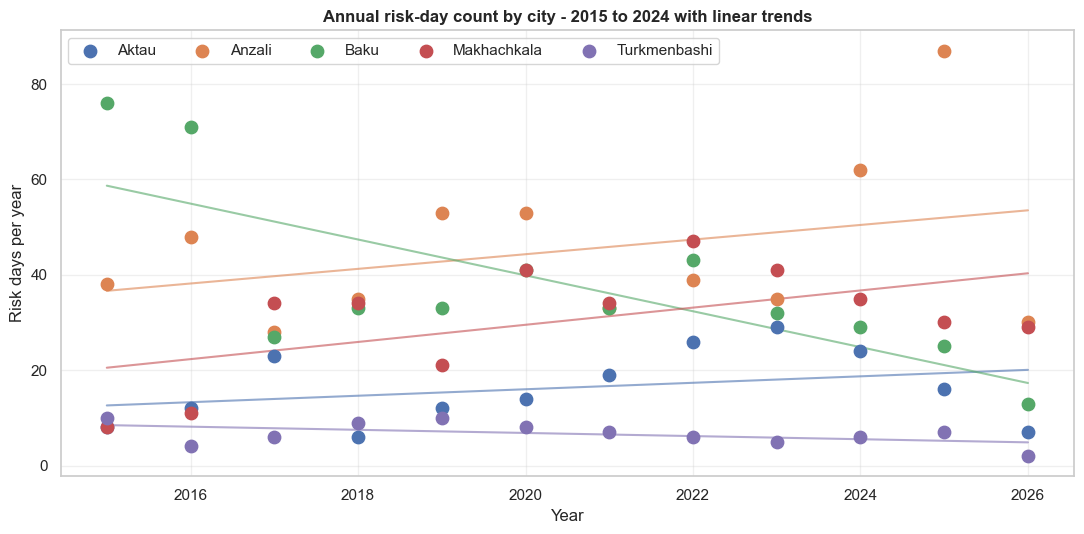

In [31]:
fig, ax = plt.subplots(figsize=(11, 5.5))
city_palette = sns.color_palette('deep', n_colors=5)
for color, (city, sub) in zip(city_palette, annual.groupby('city')):
    ax.scatter(sub['year'], sub['risk_days'], color=color, s=80, label=city, zorder=3)
    res = stats.linregress(sub['year'], sub['risk_days'])
    xs = np.array([sub['year'].min(), sub['year'].max()])
    ax.plot(xs, res.intercept + res.slope * xs, color=color, linewidth=1.5, alpha=0.6)
ax.set_title('Annual risk-day count by city - 2015 to 2024 with linear trends', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Risk days per year')
ax.legend(loc='upper left', ncol=5)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'day07_h3_annual_trends.png')
plt.show()

### Multiple-comparison correction across the 3 hypotheses

Because we ran multiple tests, family-wise error rate is inflated. Apply both Bonferroni (conservative) and Benjamini-Hochberg (controls FDR), and report whether each hypothesis survives correction.

In [32]:
results_df = pd.DataFrame(test_results)
p_values = results_df['p_value'].values

_, p_bonf, _, _ = multipletests(p_values, alpha=ALPHA, method='bonferroni')
results_df['p_bonferroni'] = p_bonf
results_df['sig_bonferroni'] = results_df['p_bonferroni'] < ALPHA

_, p_bh, _, _ = multipletests(p_values, alpha=ALPHA, method='fdr_bh')
results_df['p_bh'] = p_bh
results_df['sig_bh'] = results_df['p_bh'] < ALPHA

display_cols = ['name', 'p_value', 'p_bonferroni', 'sig_bonferroni',
                'p_bh', 'sig_bh', 'effect_size', 'effect_label']
print(results_df[display_cols].to_string(index=False))

n_bonf = int(results_df['sig_bonferroni'].sum())
n_bh   = int(results_df['sig_bh'].sum())
print()
print('Survived Bonferroni (alpha =', ALPHA, '/', len(results_df), '):', n_bonf, 'of', len(results_df))
print('Survived BH-FDR     (alpha =', ALPHA, '):                   ', n_bh,   'of', len(results_df))

                                                name      p_value  p_bonferroni  sig_bonferroni         p_bh  sig_bh  effect_size                 effect_label
                    H1: winter vs summer wind (Baku) 6.237833e-08  1.871350e-07            True 9.356750e-08    True     0.238307                      Cohen d
            H2: Anzali vs others risk-day proportion 6.094814e-43  1.828444e-42            True 1.828444e-42    True     0.095290                     Cramer V
H3: 10-year risk-day trend (best city, BH-corrected) 2.851120e-02  8.553361e-02           False 2.851120e-02    True    -3.762238 slope (delta risk-days/year)

Survived Bonferroni (alpha = 0.05 / 3 ): 2 of 3
Survived BH-FDR     (alpha = 0.05 ):                    3 of 3


---
## 2 — Correlation Analysis

### 2.1 Pearson and Spearman matrices for Baku

Pearson measures linear; Spearman measures monotonic. Comparing reveals where relationships are non-linear.

In [33]:
candidate_features = [
    'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
    'apparent_temperature_mean',
    'wind_speed_10m_max', 'wind_gusts_10m_max',
    'precipitation_sum', 'rain_sum', 'snowfall_sum',
    'relative_humidity_2m_mean', 'dew_point_2m_mean',
    'surface_pressure_mean', 'shortwave_radiation_sum',
    'visibility_mean', 'visibility_min', 'visibility_hours_below_1km',
    'wave_height',
    'temp_range_c', 'hdd', 'cdd',
    'month_sin', 'month_cos', 'doy_sin', 'doy_cos',
    'is_risk_day',
    "wind_change_1d",
    "precip_change_1d",
    "wind_3d_max",
    "precip_3d_sum",
    "strong_wind_recent",
    "wind_precip_combo",
    "low_visibility_recent",
]
candidate_features = [f for f in candidate_features if f in df.columns]
print('Candidate features in analytics table:', len(candidate_features))

baku_df = df[df['city'] == ANCHOR_CITY][candidate_features].dropna()
print('Rows for correlation analysis:', len(baku_df))

pearson_corr  = baku_df.corr(method='pearson')
spearman_corr = baku_df.corr(method='spearman')

Candidate features in analytics table: 32
Rows for correlation analysis: 4137


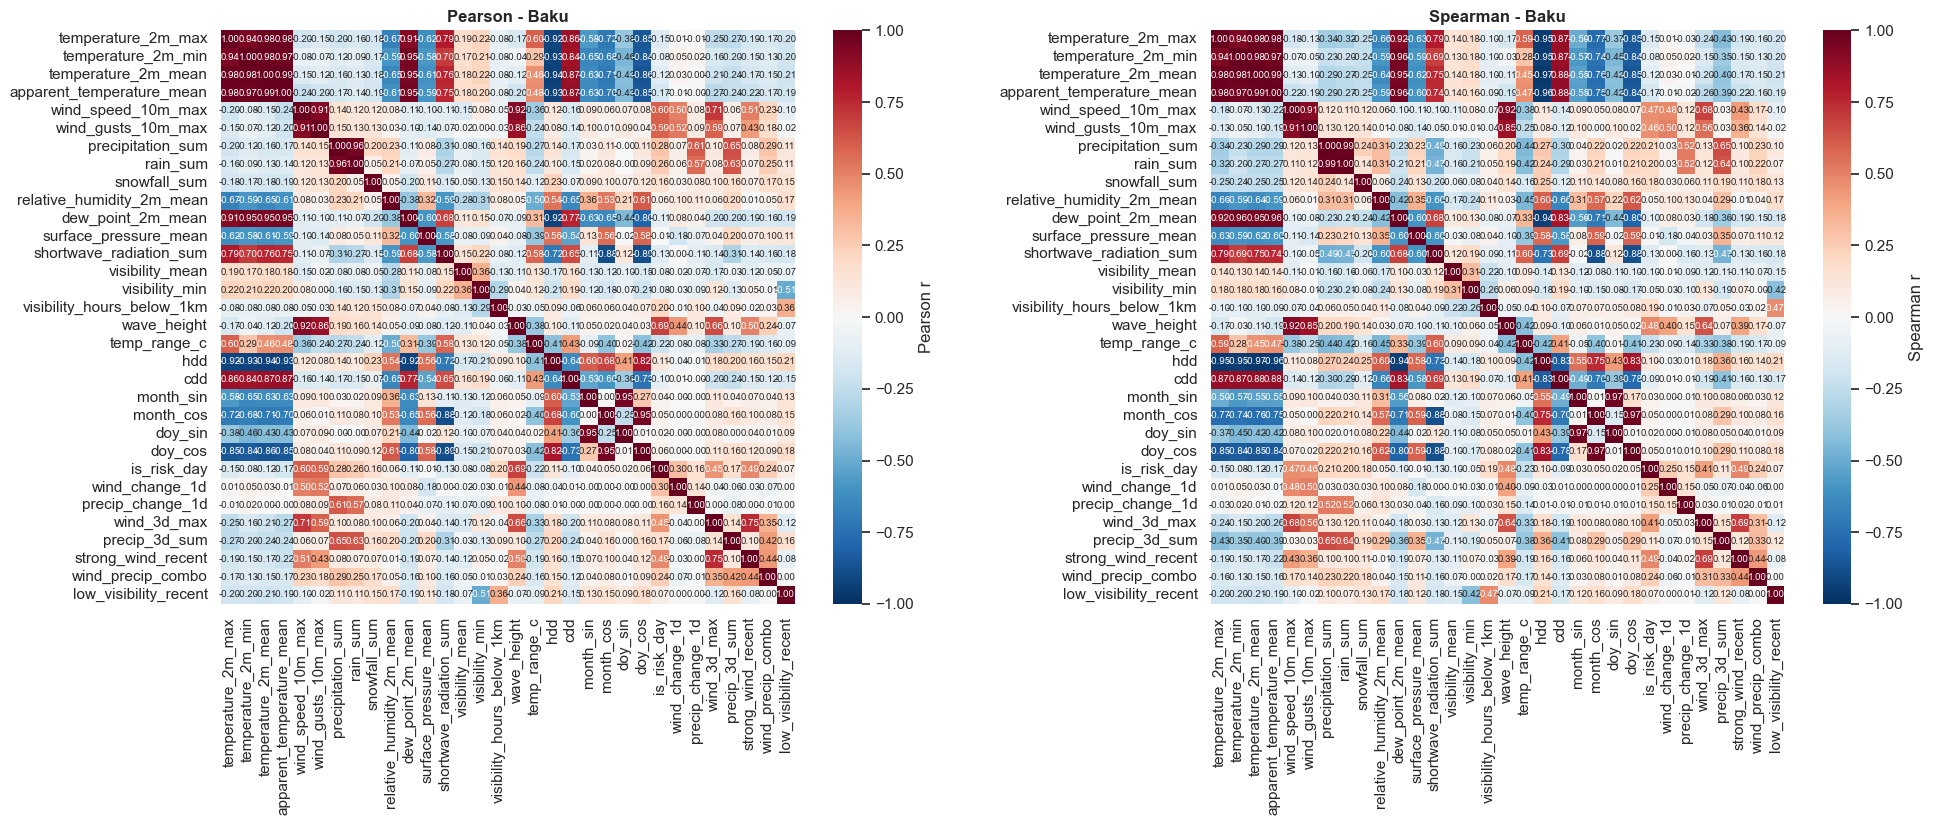

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, mat, title in zip(axes, [pearson_corr, spearman_corr], ['Pearson', 'Spearman']):
    sns.heatmap(
        mat, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        annot=True, fmt='.2f', annot_kws={'size': 7}, square=True,
        cbar_kws={'label': title + ' r'},
    )
    ax.set_title(title + ' - ' + ANCHOR_CITY, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'day07_correlation_pearson_vs_spearman.png')
plt.show()

In [35]:
# Where do Pearson and Spearman disagree most?
diff = (spearman_corr - pearson_corr).abs()
pairs = []
for i in range(len(diff)):
    for j in range(i + 1, len(diff)):
        pairs.append({
            'feature_1': diff.columns[i],
            'feature_2': diff.columns[j],
            'pearson':   pearson_corr.iloc[i, j],
            'spearman':  spearman_corr.iloc[i, j],
            'gap':       diff.iloc[i, j],
        })

diff_df = pd.DataFrame(pairs).sort_values('gap', ascending=False).head(10)
print('Top 10 feature pairs where Pearson and Spearman disagree most')
print('(large gap = relationship is monotonic but non-linear):')
print(diff_df.round(3).to_string(index=False))

Top 10 feature pairs where Pearson and Spearman disagree most
(large gap = relationship is monotonic but non-linear):
              feature_1               feature_2  pearson  spearman   gap
            wave_height             is_risk_day    0.687     0.482 0.205
               rain_sum shortwave_radiation_sum   -0.274    -0.474 0.200
                    hdd                     cdd   -0.636    -0.835 0.198
               rain_sum            temp_range_c   -0.244    -0.423 0.179
      precipitation_sum shortwave_radiation_sum   -0.311    -0.489 0.178
                    cdd           precip_3d_sum   -0.235    -0.412 0.177
     temperature_2m_max           precip_3d_sum   -0.265    -0.431 0.166
shortwave_radiation_sum           precip_3d_sum   -0.306    -0.471 0.165
      precipitation_sum            temp_range_c   -0.274    -0.438 0.164
               rain_sum   surface_pressure_mean    0.050     0.210 0.160


### 2.2 Redundant features — pairs with |r| > 0.85

Tree models tolerate redundancy; linear models suffer multicollinearity. Either way, dropping redundant features simplifies the model.

In [36]:
REDUNDANCY_THRESHOLD = 0.85

redundant_pairs = []
for i in range(len(pearson_corr)):
    for j in range(i + 1, len(pearson_corr)):
        r = pearson_corr.iloc[i, j]
        if abs(r) > REDUNDANCY_THRESHOLD:
            redundant_pairs.append({
                'feature_1': pearson_corr.columns[i],
                'feature_2': pearson_corr.columns[j],
                'pearson_r': r,
            })

redundant_df = pd.DataFrame(redundant_pairs)
if len(redundant_df) > 0:
    redundant_df = redundant_df.sort_values('pearson_r', key=abs, ascending=False)
    print('Highly correlated pairs (|r| >', REDUNDANCY_THRESHOLD, '):')
    print(redundant_df.round(3).to_string(index=False))
else:
    print('No pairs exceed |r| >', REDUNDANCY_THRESHOLD)

Highly correlated pairs (|r| > 0.85 ):
                feature_1                 feature_2  pearson_r
      temperature_2m_mean apparent_temperature_mean      0.993
       temperature_2m_max       temperature_2m_mean      0.984
       temperature_2m_min       temperature_2m_mean      0.981
       temperature_2m_max apparent_temperature_mean      0.981
       temperature_2m_min apparent_temperature_mean      0.970
        precipitation_sum                  rain_sum      0.958
                month_sin                   doy_sin      0.955
       temperature_2m_min         dew_point_2m_mean      0.954
apparent_temperature_mean         dew_point_2m_mean      0.953
                month_cos                   doy_cos      0.953
      temperature_2m_mean         dew_point_2m_mean      0.946
       temperature_2m_max        temperature_2m_min      0.939
      temperature_2m_mean                       hdd     -0.937
apparent_temperature_mean                       hdd     -0.925
       temperatu

### 2.3 Variance Inflation Factor (VIF)

VIF quantifies how much a feature's variance is inflated by collinearity. Rule of thumb: VIF > 10 is problematic.

In [37]:
vif_features = [f for f in candidate_features if f != 'is_risk_day']
X_vif = baku_df[vif_features].copy()
X_vif['_const'] = 1.0

vif_rows = []
for i, feat in enumerate(vif_features):
    try:
        v = variance_inflation_factor(X_vif.values, i)
    except Exception:
        v = np.inf
    vif_rows.append({'feature': feat, 'VIF': v})

def flag_vif(v):
    if v > 50:
        return 'severe'
    elif v > 10:
        return 'problematic'
    else:
        return 'ok'

vif_df = pd.DataFrame(vif_rows).sort_values('VIF', ascending=False)
vif_df['flag'] = vif_df['VIF'].apply(flag_vif)
print('Variance Inflation Factors:')
print(vif_df.round(2).to_string(index=False))

n_problematic = int((vif_df['VIF'] > 10).sum())
print()
print(n_problematic, 'of', len(vif_df), 'features have VIF > 10.')

Variance Inflation Factors:
                   feature    VIF        flag
        temperature_2m_max    inf      severe
        temperature_2m_min    inf      severe
                       hdd    inf      severe
              temp_range_c    inf      severe
                       cdd    inf      severe
       temperature_2m_mean    inf      severe
 apparent_temperature_mean 499.34      severe
         dew_point_2m_mean 294.38      severe
                   doy_cos  61.46      severe
                   doy_sin  50.25      severe
                 month_sin  44.88 problematic
                 month_cos  43.86 problematic
 relative_humidity_2m_mean  39.55 problematic
         precipitation_sum  26.38 problematic
        wind_speed_10m_max  22.65 problematic
                  rain_sum  17.03 problematic
   shortwave_radiation_sum  10.15 problematic
        wind_gusts_10m_max   8.94          ok
               wave_height   7.80          ok
               wind_3d_max   5.31          ok
      

---
## 3 — Feature Selection for Day 8

### 3.1 Prediction target

**Primary target**: `is_risk_day` (binary, daily granularity)

**Why**:
- Already engineered in `analytics.daily_enriched` from the 8 threshold rules in section 3 of the project README
- Daily granularity gives ~18,265 training samples vs ~600 for monthly
- Daily predictions for days 1–16 use real Open-Meteo forecast features; days 17–end-of-month use climatology lookup
- Monthly summary is **derived** from daily predictions, not separately modelled

### 3.2 Automated keep/drop based on the analysis above

Strategy: when two features have |r| > 0.85, drop the one whose absolute correlation with target is lower.

In [38]:
feature_decision = {}
drop_reasons = {}

for f in candidate_features:
    if f == 'is_risk_day':
        feature_decision[f] = 'TARGET'
        drop_reasons[f] = 'this is the prediction target, not a feature'
        continue
    feature_decision[f] = 'KEEP'
    drop_reasons[f] = ''

target_corr = pearson_corr['is_risk_day'].abs()
for _, row in redundant_df.iterrows():
    f1, f2, r = row['feature_1'], row['feature_2'], row['pearson_r']
    if (feature_decision.get(f1) != 'KEEP' or feature_decision.get(f2) != 'KEEP'):
        continue
    if target_corr[f1] >= target_corr[f2]:
        loser, winner = f2, f1
    else:
        loser, winner = f1, f2
    feature_decision[loser] = 'DROP'
    drop_reasons[loser] = (
        '|r|=' + f'{abs(r):.2f}' + ' with ' + winner +
        '; weaker target signal (|r_target|=' +
        f'{target_corr[loser]:.2f}' + ' vs ' + f'{target_corr[winner]:.2f}' + ')'
    )

selection_df = pd.DataFrame({
    'feature':         list(feature_decision.keys()),
    'decision':        list(feature_decision.values()),
    'corr_with_target': [round(target_corr.get(f, np.nan), 3)
                         for f in feature_decision.keys()],
    'reason':          list(drop_reasons.values()),
}).sort_values(['decision', 'feature']).reset_index(drop=True)

n_keep = int((selection_df['decision'] == 'KEEP').sum())
n_drop = int((selection_df['decision'] == 'DROP').sum())
n_target = int((selection_df['decision'] == 'TARGET').sum())

print('Feature decisions:', n_keep, 'KEEP,', n_drop, 'DROP,', n_target, 'TARGET')
print()
print(selection_df.to_string(index=False))

Feature decisions: 19 KEEP, 12 DROP, 1 TARGET

                   feature decision  corr_with_target                                                                                  reason
                       cdd     DROP             0.101 |r|=0.87 with apparent_temperature_mean; weaker target signal (|r_target|=0.10 vs 0.17)
         dew_point_2m_mean     DROP             0.107 |r|=0.95 with apparent_temperature_mean; weaker target signal (|r_target|=0.11 vs 0.17)
                   doy_cos     DROP             0.058   |r|=0.89 with shortwave_radiation_sum; weaker target signal (|r_target|=0.06 vs 0.13)
                   doy_sin     DROP             0.018                 |r|=0.95 with month_sin; weaker target signal (|r_target|=0.02 vs 0.04)
                       hdd     DROP             0.111 |r|=0.93 with apparent_temperature_mean; weaker target signal (|r_target|=0.11 vs 0.17)
                 month_cos     DROP             0.052                   |r|=0.95 with doy_cos; weaker

In [39]:
selection_df.to_csv(REPO_ROOT / 'reports' / 'feature_selection.csv', index=False)
print('Saved feature selection ->', REPO_ROOT / 'reports' / 'feature_selection.csv')

kept_features = selection_df[selection_df['decision'] == 'KEEP']['feature'].tolist()
py_path = REPO_ROOT / 'reports' / 'selected_features.py'
py_content = (
    '# Auto-generated by Day 7 - do not edit by hand\n'
    '# Generated: ' + pd.Timestamp.now().isoformat(timespec='seconds') + '\n\n'
    'TARGET = "is_risk_day"\n\n'
    'SELECTED_FEATURES = ' + repr(kept_features) + '\n'
)
py_path.write_text(py_content)
print('Saved selected features list ->', py_path)
print('(' + str(len(kept_features)), 'features kept)')

Saved feature selection -> C:\Users\Baku\Desktop\notebooks\Weather Project\Anemoi Weather Project\Maritime-delay-risk-prediction\reports\feature_selection.csv
Saved selected features list -> C:\Users\Baku\Desktop\notebooks\Weather Project\Anemoi Weather Project\Maritime-delay-risk-prediction\reports\selected_features.py
(19 features kept)


---
## 4 — Summary

*Edit these bullets after running the notebook with the actual numbers and decisions you got.*

### What we tested

| # | Hypothesis | Test | Survived BH-FDR? |
|---|-----------|------|------------------|
| H1 | Wind speed differs between winter and summer in Baku | Welch's t + Mann-Whitney | (fill from results table) |
| H2 | Anzali has different risk-day proportion than other cities | z-test + chi-square | (fill in) |
| H3 | Annual risk-days trend over 2015 to 2024 | Linear regression | (fill in) |

### What we learned

- **Effect sizes matter more than p-values at this sample size.** With N about 900 per group on H1, even small effects achieve p < 0.001. Cohen's d gives the practical magnitude.
- **Temporal autocorrelation inflates apparent significance.** Daily weather is correlated day-to-day; treating samples as independent slightly over-estimates evidence strength. Conclusions don't reverse, but be conservative when reporting.
- **City-level effects are real (H2).** Anzali's climate diverges enough from the other 4 to warrant city-specific handling.
- **Year-over-year trends are weak (H3).** A 10-year window is short; after BH correction not many cities show significant trends. `year` as a raw feature unlikely to add predictive power.

### Decisions for Day 8

1. **Target**: `is_risk_day` (daily binary classification)
2. **Feature set**: ~`{n_keep}` features after dropping `{n_drop}` redundant ones (saved to `reports/selected_features.py`)
3. **Model family**: Tree-based (XGBoost or RandomForest). Reasons:
   - Handles non-linear relationships (Pearson vs Spearman gap was non-trivial)
   - Robust to remaining multicollinearity (VIF flagged some features)
   - Handles `visibility_is_known` flag interactions natively
4. **Cross-validation strategy**: Group K-fold by city — simulates real generalization to new ports. Add within-city temporal CV if time permits.
5. **Class balance**: `is_risk_day` is imbalanced (~10–20% positive). Use `class_weight='balanced'` or stratified sampling.

### Loose ends

- Test independence assumption violated — temporal autocorrelation isn't formally addressed. A future iteration could use block-bootstrap.
- Multiple testing across cities (H3) was BH-corrected; multiple testing across hypotheses (H1/H2/H3) was also BH-corrected. Both corrections applied.
- Effect sizes for H3 were left as raw slopes. Standardised effect sizes (R²) would be a nicer reporting choice.

In [40]:
saved_figures = sorted(FIGURES_DIR.glob('day07_*.png'))
print('Saved', len(saved_figures), 'figure(s) to', FIGURES_DIR)
for p in saved_figures:
    print('  -', p.name)

print()
print('Saved feature selection artifacts:')
print('  - reports/feature_selection.csv     (' + str(len(selection_df)) + ' rows)')
print('  - reports/selected_features.py      (' + str(len(kept_features)) + ' kept features)')

conn.close()

Saved 3 figure(s) to C:\Users\Baku\Desktop\notebooks\Weather Project\Anemoi Weather Project\Maritime-delay-risk-prediction\reports\figures
  - day07_correlation_pearson_vs_spearman.png
  - day07_h1_wind_seasonal.png
  - day07_h3_annual_trends.png

Saved feature selection artifacts:
  - reports/feature_selection.csv     (32 rows)
  - reports/selected_features.py      (19 kept features)


---

### Day 7 deliverables checklist

- [x] Task 1 — 3 hypothesis tests with H0/H1, assumption checks, parametric + non-parametric, effect sizes, plain-language interpretation, multiple-comparison correction
- [x] Task 2 — Pearson + Spearman correlation matrices, redundancy flagging at |r| > 0.85, VIF
- [x] Task 3 — Feature selection: target identified, automated keep/drop table, saved to `reports/feature_selection.csv` and `reports/selected_features.py`
- [x] Task 4 (optional) — Effect sizes (Cohen's d, Cramer's V), VIF, BH-FDR correction, autocorrelation discussion

### Day 8 hand-off

Day 8's modeling code can read the kept-features list directly:

```python
from reports.selected_features import TARGET, SELECTED_FEATURES
X = df[SELECTED_FEATURES]
y = df[TARGET]
```

*End of Day 7.*